## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_gdf = gpd.read_file(f"{folder_path}/elladitsa_nomoi.shp",  encoding=dec)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf = greece_gdf.to_crs(epsg=4326)
greece_regions_gdf = greece_regions_gdf.to_crs(epsg=4326)
rivers_gdf = rivers_gdf.to_crs(epsg=4326)

In [5]:
greece_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37..."
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((20.87623 40.33865, 20.87576 40.33726..."
3,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."


In [6]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
#choose the correct region

nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ']
nuts2_gdf.head()

,PER,geometry
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."


In [8]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
      
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [9]:
nuts2_gdf.head()

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
2,42000000,42000000,Ν. ΛΑΡΙΣΑΣ,N. LARISAS,282156,ΛΑΡΙΣΑ,479120.018907,5.385277e+09,"POLYGON ((22.18705 40.19547, 22.18798 40.19535..."
3,64000000,64000000,Ν. ΧΑΛΚΙΔΙΚΗΣ,N. CHALKIDIKIS,96849,ΠΟΛΥΓΥΡΟΣ,622192.667794,2.914905e+09,"MULTIPOLYGON (((23.89957 39.96273, 23.89919 39..."
4,62000000,62000000,Ν. ΣΕΡΡΩΝ,N. SERRON,194483,ΣΕΡΡΕΣ,365201.973231,3.971351e+09,"POLYGON ((23.45690 41.40316, 23.45749 41.40311..."


<AxesSubplot:>

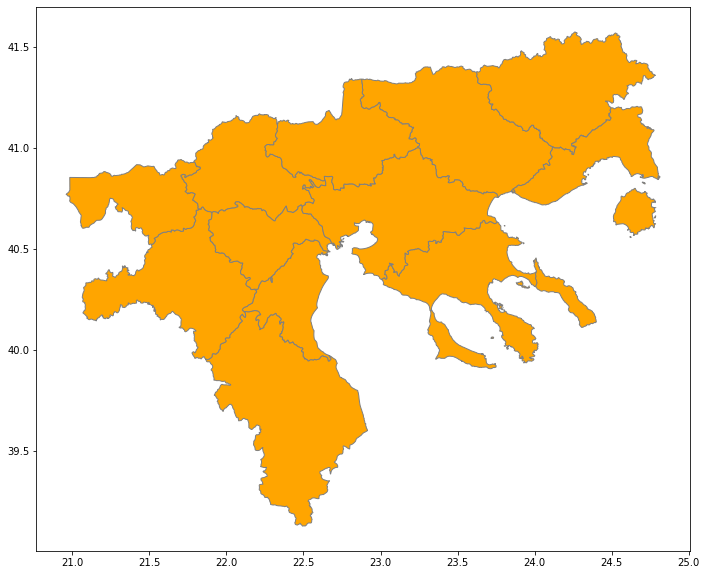

In [10]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [11]:
nuts2_gdf.NAME_GR.unique()

array(['Ν. ΠΙΕΡΙΑΣ', 'Ν. ΠΕΛΛΑΣ', 'Ν. ΛΑΡΙΣΑΣ', 'Ν. ΧΑΛΚΙΔΙΚΗΣ',
       'Ν. ΣΕΡΡΩΝ', 'Ν. ΚΟΖΑΝΗΣ', 'Ν. ΗΜΑΘΙΑΣ', 'Ν. ΦΛΩΡΙΝΑΣ',
       'Ν. ΔΡΑΜΑΣ', 'Ν. ΚΑΒΑΛΑΣ', 'ΑΓΙΟ ΟΡΟΣ', 'Ν. ΘΕΣΣΑΛΟΝΙΚΗΣ',
       'Ν. ΚΙΛΚΙΣ'], dtype=object)

In [12]:
#check QGIS for wrong lau1 units

In [13]:
wrong_list = ['Ν. ΛΑΡΙΣΑΣ' ,'Ν. ΚΟΖΑΝΗΣ', 'Ν. ΦΛΩΡΙΝΑΣ', 'Ν. ΔΡΑΜΑΣ', 'Ν. ΚΑΒΑΛΑΣ',
 'ΑΓΙΟ ΟΡΟΣ']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME_GR'].isin(wrong_list)].copy()

In [14]:
nuts2_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
3,64000000,64000000,Ν. ΧΑΛΚΙΔΙΚΗΣ,N. CHALKIDIKIS,96849,ΠΟΛΥΓΥΡΟΣ,622192.667794,2.914905e+09,"MULTIPOLYGON (((23.89957 39.96273, 23.89919 39..."
4,62000000,62000000,Ν. ΣΕΡΡΩΝ,N. SERRON,194483,ΣΕΡΡΕΣ,365201.973231,3.971351e+09,"POLYGON ((23.45690 41.40316, 23.45749 41.40311..."
6,53000000,53000000,Ν. ΗΜΑΘΙΑΣ,N. IMATHIAS,142471,ΒΕΡΟΙΑ,246547.416792,1.703493e+09,"POLYGON ((22.08969 40.72849, 22.09136 40.72851..."


In [15]:
nuts2_gdf.drop(columns=['PARENT', 'ESYE_ID', 'NAME_ENG', 'POP', 'EDRA', 'SHAPE_LENG', 'SHAPE_AREA'], inplace = True)
nuts2_gdf.rename(columns={"NAME_GR": "nuts3"}, inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'nuts3')

In [16]:
nuts2_gdf.head(5)

,nuts3,geometry
0,πιεριας,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,πελλας,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
2,χαλκιδικης,"MULTIPOLYGON (((23.89957 39.96273, 23.89919 39..."
3,σερρων,"POLYGON ((23.45690 41.40316, 23.45749 41.40311..."
4,ημαθιας,"POLYGON ((22.08969 40.72849, 22.09136 40.72851..."


<AxesSubplot:>

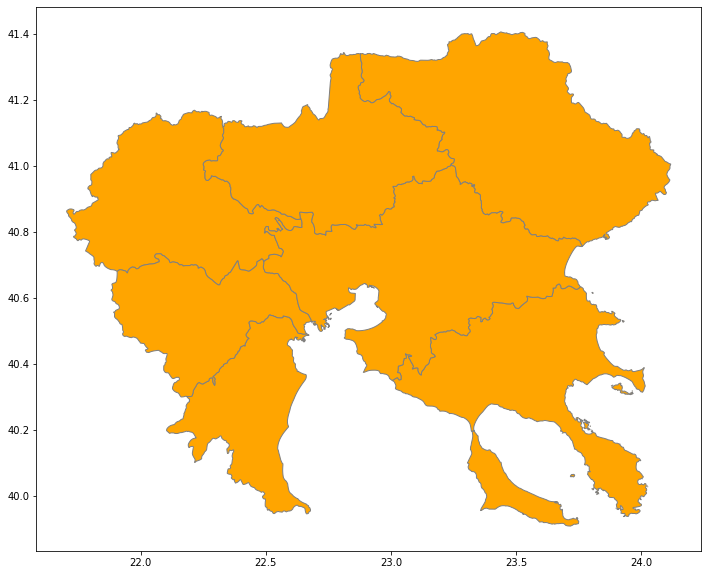

In [17]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [18]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [19]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,21,GR0009000400010100H,None,None,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,yes,17199.809546,"LINESTRING (21.73202 40.68216, 21.79637 40.773..."
1,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
2,227,GR001100040B230320N,ÁÃÉÙÍ ÁÍÁÑÃÕÑÙÍ Ñ.,AGION ANARGYRON S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,7703.516408,"LINESTRING (23.54881 41.12369, 23.54925 41.123..."
3,232,GR0009000400230100N,ÌÁÕÑÏÍÅÑÉ Ð.,MAVRONERI R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,15512.426035,"LINESTRING (22.39929 40.29495, 22.39973 40.294..."
4,233,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,22851.141835,"LINESTRING (23.44204 40.78918, 23.44706 40.789..."


<AxesSubplot:>

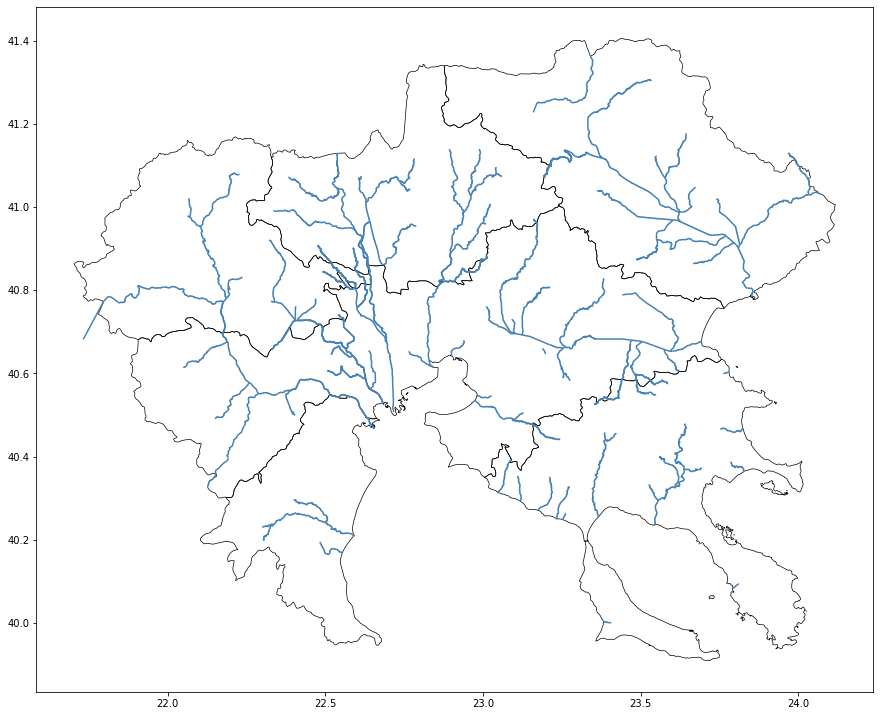

In [20]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [21]:
nuts3_units = nuts2_gdf['nuts3'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in CMacedonia (from shapefile): 7


In [22]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [23]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='nuts3', dimension=4.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\notebooks\CMacedonia\../../../../Modules\preprocessing_utils.py:38: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is depr

In [24]:
df_grid.rename(columns={"NAME": "nuts3"}, inplace = True)

<AxesSubplot:>

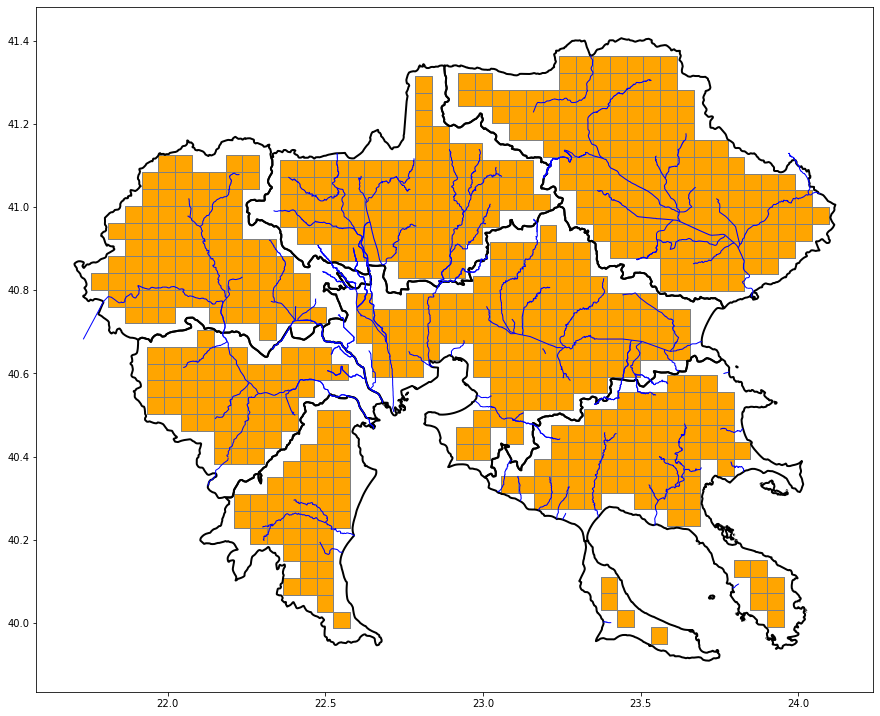

In [25]:
ax = nuts2_rivers_gdf.plot(figsize=(15, 15), cmap='jet', color='blue', lw=1)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [26]:
grid_nuts3 = df_grid['nuts3'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 7


In [27]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['nuts3'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['nuts3'] = lost_lau1['nuts3']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [28]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [29]:
nuts2_grid

,geometry,nuts3,x,y
0,"POLYGON ((22.26157 40.22887, 22.26157 40.26930...",πιεριας,22.23521,40.24909
1,"POLYGON ((22.26157 40.26930, 22.26157 40.30972...",πιεριας,22.23521,40.28951
2,"POLYGON ((22.31430 40.18845, 22.31430 40.22887...",πιεριας,22.28794,40.20866
3,"POLYGON ((22.31430 40.22887, 22.31430 40.26930...",πιεριας,22.28794,40.24909
4,"POLYGON ((22.31430 40.26930, 22.31430 40.30972...",πιεριας,22.28794,40.28951
...,...,...,...,...
641,"POLYGON ((23.10452 41.07332, 23.10452 41.11375...",κιλκις,23.07783,41.09354
642,"POLYGON ((23.15792 40.99247, 23.15792 41.03290...",κιλκις,23.13122,41.01269
643,"POLYGON ((23.15792 41.03290, 23.15792 41.07332...",κιλκις,23.13122,41.05311
644,"POLYGON ((23.15792 41.07332, 23.15792 41.11375...",κιλκις,23.13122,41.09354


In [30]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [31]:
nuts2_grid['nuts2'] = NUTS2_EL

In [32]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [33]:
nuts2_grid

,shape,nuts3,x,y,nuts2
0,"POLYGON ((22.26157 40.22887, 22.26157 40.26930...",πιεριας,22.23521,40.24909,κεντρικης μακεδονιας
1,"POLYGON ((22.26157 40.26930, 22.26157 40.30972...",πιεριας,22.23521,40.28951,κεντρικης μακεδονιας
2,"POLYGON ((22.31430 40.18845, 22.31430 40.22887...",πιεριας,22.28794,40.20866,κεντρικης μακεδονιας
3,"POLYGON ((22.31430 40.22887, 22.31430 40.26930...",πιεριας,22.28794,40.24909,κεντρικης μακεδονιας
4,"POLYGON ((22.31430 40.26930, 22.31430 40.30972...",πιεριας,22.28794,40.28951,κεντρικης μακεδονιας
...,...,...,...,...,...
641,"POLYGON ((23.10452 41.07332, 23.10452 41.11375...",κιλκις,23.07783,41.09354,κεντρικης μακεδονιας
642,"POLYGON ((23.15792 40.99247, 23.15792 41.03290...",κιλκις,23.13122,41.01269,κεντρικης μακεδονιας
643,"POLYGON ((23.15792 41.03290, 23.15792 41.07332...",κιλκις,23.13122,41.05311,κεντρικης μακεδονιας
644,"POLYGON ((23.15792 41.07332, 23.15792 41.11375...",κιλκις,23.13122,41.09354,κεντρικης μακεδονιας


In [34]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [35]:
nuts2_grid_points

,shape,nuts3,x,y,nuts2,geometry
0,"POLYGON ((22.26157 40.22887, 22.26157 40.26930...",πιεριας,22.23521,40.24909,κεντρικης μακεδονιας,POINT (22.23521 40.24909)
1,"POLYGON ((22.26157 40.26930, 22.26157 40.30972...",πιεριας,22.23521,40.28951,κεντρικης μακεδονιας,POINT (22.23521 40.28951)
2,"POLYGON ((22.31430 40.18845, 22.31430 40.22887...",πιεριας,22.28794,40.20866,κεντρικης μακεδονιας,POINT (22.28794 40.20866)
3,"POLYGON ((22.31430 40.22887, 22.31430 40.26930...",πιεριας,22.28794,40.24909,κεντρικης μακεδονιας,POINT (22.28794 40.24909)
4,"POLYGON ((22.31430 40.26930, 22.31430 40.30972...",πιεριας,22.28794,40.28951,κεντρικης μακεδονιας,POINT (22.28794 40.28951)
...,...,...,...,...,...,...
641,"POLYGON ((23.10452 41.07332, 23.10452 41.11375...",κιλκις,23.07783,41.09354,κεντρικης μακεδονιας,POINT (23.07783 41.09354)
642,"POLYGON ((23.15792 40.99247, 23.15792 41.03290...",κιλκις,23.13122,41.01269,κεντρικης μακεδονιας,POINT (23.13122 41.01269)
643,"POLYGON ((23.15792 41.03290, 23.15792 41.07332...",κιλκις,23.13122,41.05311,κεντρικης μακεδονιας,POINT (23.13122 41.05311)
644,"POLYGON ((23.15792 41.07332, 23.15792 41.11375...",κιλκις,23.13122,41.09354,κεντρικης μακεδονιας,POINT (23.13122 41.09354)


<AxesSubplot:>

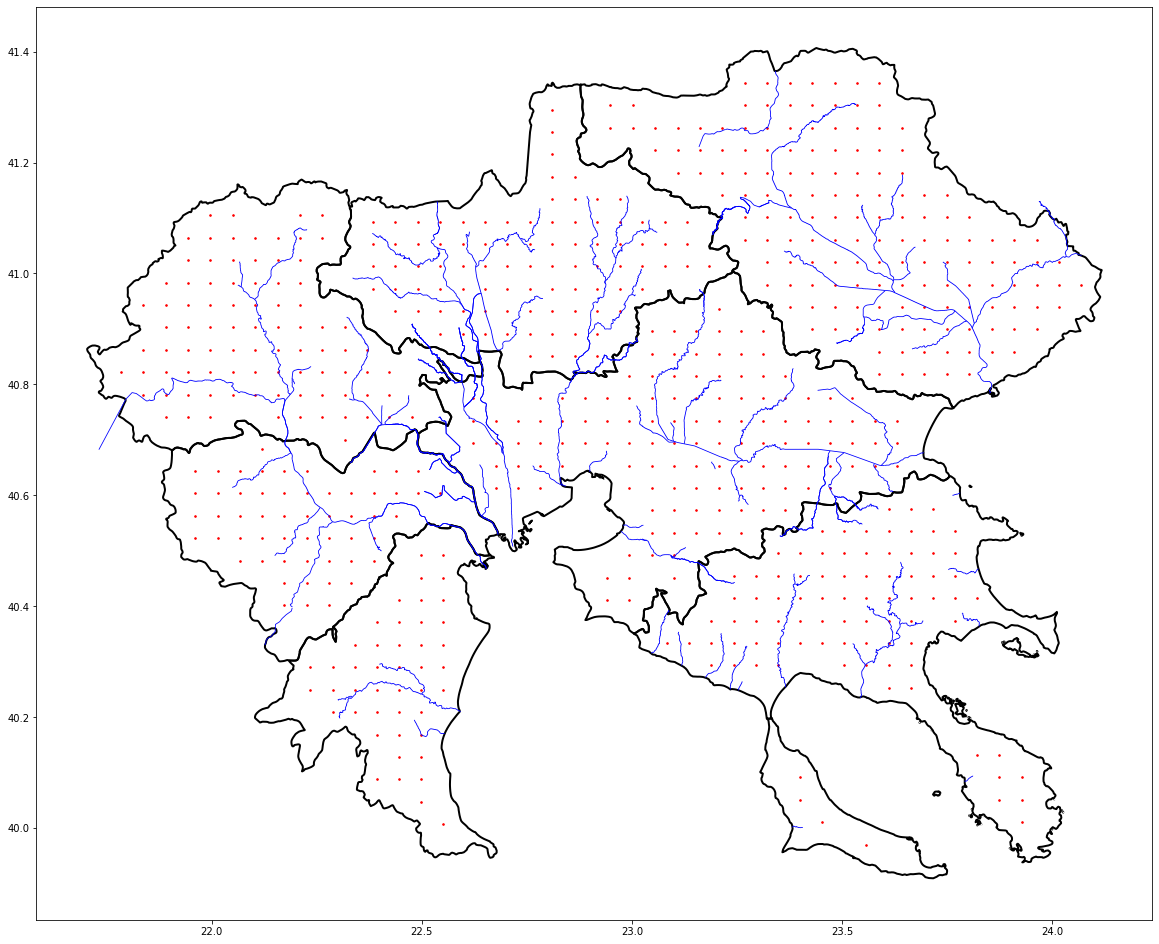

In [38]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=0.8)

In [39]:
final_grid = nuts2_grid[['nuts2', 'nuts3', 'x', 'y']].sort_values(by=['nuts3'])
final_grid.reset_index(drop = True, inplace= True)

In [40]:
final_grid

,nuts2,nuts3,x,y
0,κεντρικης μακεδονιας,ημαθιας,21.96145,40.52252
1,κεντρικης μακεδονιας,ημαθιας,22.22648,40.60337
2,κεντρικης μακεδονιας,ημαθιας,22.22648,40.64380
3,κεντρικης μακεδονιας,ημαθιας,22.27948,40.40125
4,κεντρικης μακεδονιας,ημαθιας,22.27948,40.44167
...,...,...,...,...
641,κεντρικης μακεδονιας,χαλκιδικης,23.61091,40.25247
642,κεντρικης μακεδονιας,χαλκιδικης,23.61091,40.29289
643,κεντρικης μακεδονιας,χαλκιδικης,23.61091,40.33332
644,κεντρικης μακεδονιας,χαλκιδικης,23.61091,40.41417


In [41]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)